In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
spark = SparkSession.builder \
    .appName("NYC Yellow Taxi EDA") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [6]:
df = spark.read.csv(
    '/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data',
    header=True,
    inferSchema=True
)

In [7]:
df.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude   |pickup_latitude   |RatecodeID|store_and_fwd_flag|dropoff_longitude  |dropoff_latitude  |payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|2       |2016-01-01 00:00:00 |2016-01-01 00:00:00  |2              |1.10         |-73.990371704101563|40.734695434570313|1       

In [8]:
print("Number of Rows:", df.count())
print("Number of Columns:", len(df.columns))

Number of Rows: 47248845
Number of Columns: 19


In [9]:
print(df.columns)

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [10]:
df.printSchema()

root
 |-- VendorID: string (nullable = true)
 |-- tpep_pickup_datetime: string (nullable = true)
 |-- tpep_dropoff_datetime: string (nullable = true)
 |-- passenger_count: string (nullable = true)
 |-- trip_distance: string (nullable = true)
 |-- pickup_longitude: string (nullable = true)
 |-- pickup_latitude: string (nullable = true)
 |-- RatecodeID: string (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: string (nullable = true)
 |-- dropoff_latitude: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: string (nullable = true)
 |-- extra: string (nullable = true)
 |-- mta_tax: string (nullable = true)
 |-- tip_amount: string (nullable = true)
 |-- tolls_amount: string (nullable = true)
 |-- improvement_surcharge: string (nullable = true)
 |-- total_amount: string (nullable = true)



In [11]:
df.describe().show()

+-------+-------------------+--------------------+---------------------+------------------+-----------------+--------------------+-------------------+------------------+------------------+-------------------+------------------+-------------------+------------------+------------------+--------------------+-----------------+-------------------+---------------------+-----------------+
|summary|           VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|   passenger_count|    trip_distance|    pickup_longitude|    pickup_latitude|        RatecodeID|store_and_fwd_flag|  dropoff_longitude|  dropoff_latitude|       payment_type|       fare_amount|             extra|             mta_tax|       tip_amount|       tolls_amount|improvement_surcharge|     total_amount|
+-------+-------------------+--------------------+---------------------+------------------+-----------------+--------------------+-------------------+------------------+------------------+-------------------+------------------+---

In [12]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude|pickup_latitude|RatecodeID|store_and_fwd_flag|dropoff_longitude|dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       0|                   0|                    0|              0|            0|               0|              0|         0|                 0|              

In [13]:
total_rows = df.count()
unique_rows = df.dropDuplicates().count()

print("Total Rows:", total_rows)
print("Unique Rows:", unique_rows)
print("Duplicate Rows:", total_rows - unique_rows)

Total Rows: 47248845
Unique Rows: 47248459
Duplicate Rows: 386


In [16]:
from pyspark.sql.functions import expr, col


df = df.withColumn("passenger_count", expr("try_cast(passenger_count as double)")) \
       .withColumn("trip_distance", expr("try_cast(trip_distance as double)")) \
       .withColumn("fare_amount", expr("try_cast(fare_amount as double)"))


df_clean = df.filter(col("trip_distance") > 0) \
             .filter(col("fare_amount") > 0) \
             .filter(col("passenger_count") > 0)

print("Rows After Cleaning:", df_clean.count())

Rows After Cleaning: 46938743


In [17]:
df_clean = df_clean.withColumn("pickup_hour", hour(col("tpep_pickup_datetime")))
df_clean = df_clean.withColumn("pickup_day", dayofweek(col("tpep_pickup_datetime")))

df_clean.select("pickup_hour","pickup_day").show(5)

+-----------+----------+
|pickup_hour|pickup_day|
+-----------+----------+
|          0|         6|
|          0|         6|
|          0|         6|
|          0|         6|
|          0|         6|
+-----------+----------+
only showing top 5 rows


In [18]:
df_clean.groupBy("pickup_hour").count().orderBy("pickup_hour").show()

+-----------+-------+
|pickup_hour|  count|
+-----------+-------+
|          0|1678195|
|          1|1234880|
|          2| 908909|
|          3| 680498|
|          4| 505685|
|          5| 469782|
|          6|1024607|
|          7|1746514|
|          8|2143790|
|          9|2162120|
|         10|2095438|
|         11|2178717|
|         12|2314499|
|         13|2311578|
|         14|2412860|
|         15|2374174|
|         16|2140207|
|         17|2507801|
|         18|2969418|
|         19|2960826|
+-----------+-------+
only showing top 20 rows


In [19]:
df_clean.groupBy("payment_type").count().show()

+------------+--------+
|payment_type|   count|
+------------+--------+
|           3|  121786|
|           1|30762490|
|           4|   43180|
|           2|16011285|
|           5|       2|
+------------+--------+



In [20]:
df_clean.select(avg("fare_amount")).show()

+------------------+
|  avg(fare_amount)|
+------------------+
|12.346443253071325|
+------------------+



In [21]:
df_clean.select(avg("trip_distance")).show()

+------------------+
|avg(trip_distance)|
+------------------+
| 7.514103304172376|
+------------------+



In [23]:
sample_df = df_clean.select(
    "trip_distance",
    "fare_amount",
    "passenger_count"
).sample(False, 0.01).toPandas()

print("Sample Data Created Successfully")
print(sample_df.head())

Sample Data Created Successfully
   trip_distance  fare_amount  passenger_count
0            1.6          6.5              2.0
1            0.1          3.0              1.0
2            6.2         21.0              2.0
3            6.1         26.5              1.0
4           13.3         37.5              1.0


In [24]:
print(sample_df[['trip_distance','fare_amount']].corr())

               trip_distance  fare_amount
trip_distance       1.000000     0.000437
fare_amount         0.000437     1.000000


In [25]:
sample_df

,trip_distance,fare_amount,passenger_count
0,1.60,6.5,2.0
1,0.10,3.0,1.0
2,6.20,21.0,2.0
3,6.10,26.5,1.0
4,13.30,37.5,1.0
...,...,...,...
469331,3.10,12.0,1.0
469332,3.70,14.0,1.0
469333,5.80,27.5,1.0
469334,5.00,17.5,1.0


In [43]:
clean_plot = df_clean.filter(col("trip_distance") < 50) \
                     .filter(col("fare_amount") < 200)

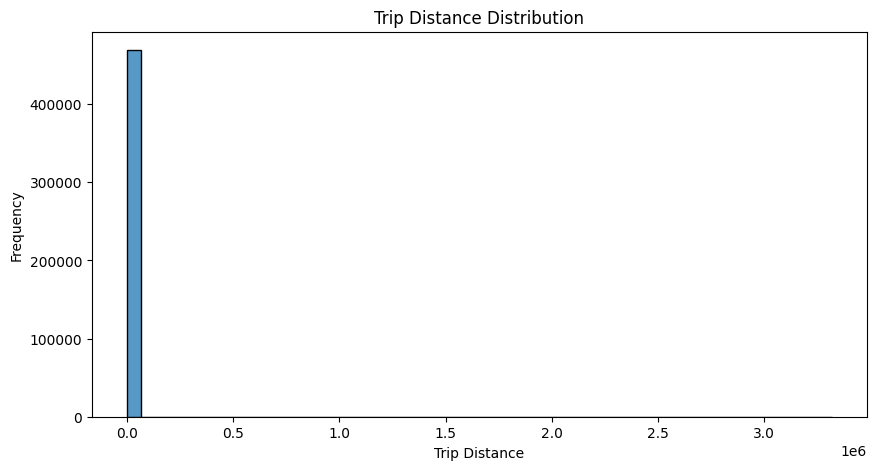

In [44]:
plt.figure(figsize=(10,5))
sns.histplot(sample_df['trip_distance'], bins=50)
plt.title("Trip Distance Distribution")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.show()

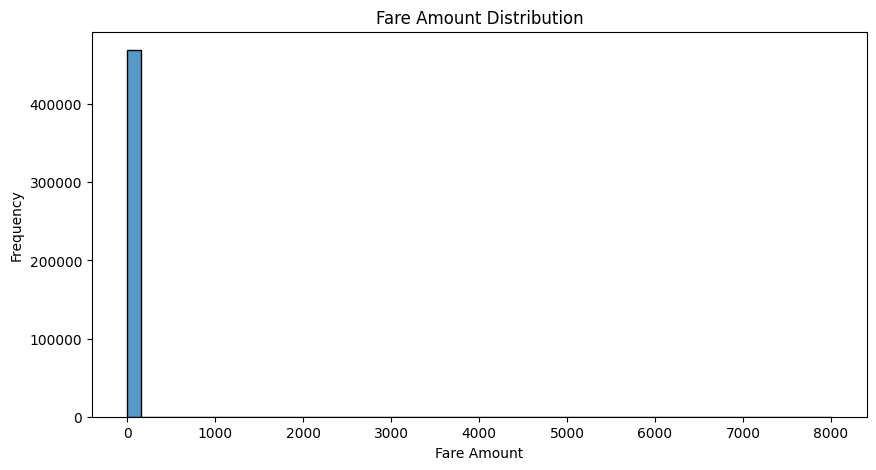

In [45]:
plt.figure(figsize=(10,5))
sns.histplot(sample_df['fare_amount'], bins=50)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()

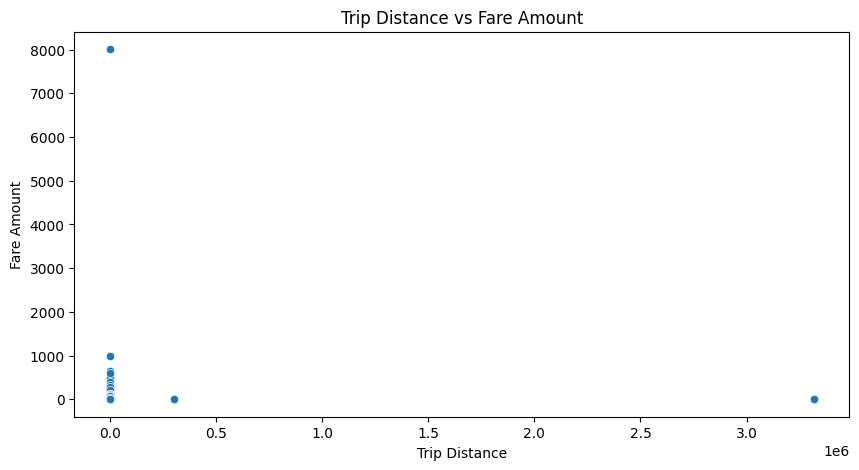

In [47]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=sample_df['trip_distance'],
    y=sample_df['fare_amount']
)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.show()

In [48]:
peak_hours = df_clean.groupBy("pickup_hour").count().orderBy("pickup_hour").toPandas()

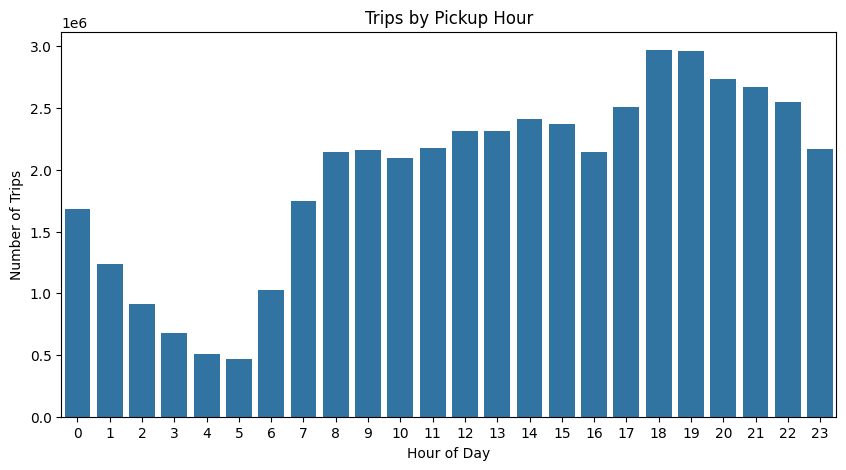

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='pickup_hour',
    y='count',
    data=peak_hours
)
plt.title("Trips by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()